In [5]:
!pip install ultralytics


In [6]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo checks

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6960.6/8062.4 GB disk)

OS                     Linux-6.12.90+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.13
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    31.35 GB
Disk                   6960.6/8062.4 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              4
GPU                    Tesla T4, 14912MiB
GPU count              2
CUDA                   12.8

numpy                  ✅ 2.4.6>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅ 2.10.0+cu128!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision            ✅ 0.25.0

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="zx3ilJ1MB6oUz9xP9KWS")
project = rf.workspace("ekanshs-workspace-j7ydu").project("skin-lesion-classification-sh4sk-u1iyi")
version = project.version(1)
dataset = version.download("folder")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.5 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery


Extracting Dataset Version Zip to skin-lesion-classification-1 in folder:: 100%|██████████| 8558/8558 [00:00<00:00, 12570.84it/s]


In [2]:
import os
data_path = "/kaggle/working/skin-lesion-classification-1"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(data_path, split)
    if os.path.exists(split_path):
        classes = os.listdir(split_path)
        print(f"{split}: {len(classes)} classes")
        for cls in sorted(classes):
            count = len(os.listdir(os.path.join(split_path, cls)))
            print(f"  {cls}: {count} images")

train: 8 classes
  AK: 910 images
  BCC: 1124 images
  BKL: 1140 images
  DF: 312 images
  MEL: 1164 images
  NV: 1180 images
  SCC: 810 images
  VASC: 394 images
valid: 8 classes
  AK: 130 images
  BCC: 185 images
  BKL: 151 images
  DF: 54 images
  MEL: 170 images
  NV: 171 images
  SCC: 112 images
  VASC: 33 images
test: 8 classes
  AK: 66 images
  BCC: 74 images
  BKL: 85 images
  DF: 29 images
  MEL: 83 images
  NV: 95 images
  SCC: 62 images
  VASC: 23 images


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8m-cls.pt")

results = model.train(
    data=data_path,
    epochs=80,
    imgsz=224,
    batch=32,       
    lr0=0.001,
    patience=16,
    project="/kaggle/working/skin_lesion_output",
    name="run1",

)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/skin-lesion-classification-1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-2, nbs=64, nms=False, opset=None, optimize=False

In [10]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/skin_lesion_output/run1-2/weights/best.pt")

metrics = model.val()
print(f"Top-1 Accuracy: {metrics.top1:.2%}")
print(f"Top-5 Accuracy: {metrics.top5:.2%}")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,772,904 parameters, 0 gradients, 41.6 GFLOPs
train: /kaggle/working/skin-lesion-classification-1/train... found 7034 images in 8 classes ✅ 
val: /kaggle/working/skin-lesion-classification-1/valid... found 1006 images in 8 classes ✅ 
test: /kaggle/working/skin-lesion-classification-1/test... found 517 images in 8 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 346.9±95.4 MB/s, size: 9.6 KB)
val: Scanning /kaggle/working/skin-lesion-classification-1/valid... 1006 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1006/1006 421.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 63/63 29.7it/s 2.1s0.0s
                   all      0.661      0.977
Speed: 0.1ms preprocess, 1.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val-2
Top-1 Accuracy: 66.10%
Top-5 Accuracy: 97.71%



image 1/1 /kaggle/working/skin-lesion-classification-1/test/AK/ISIC_0066180_jpg.rf.418ecbf942876810c1476058f7616247.jpg: 224x224 AK 1.00, SCC 0.00, MEL 0.00, BCC 0.00, BKL 0.00, 6.2ms
Speed: 1.5ms preprocess, 6.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Predicted: AK
Confidence: 99.94%
Actual class: AK


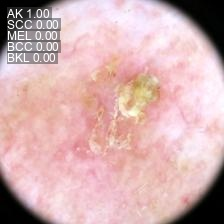

In [21]:
from ultralytics import YOLO
from IPython.display import Image as IPImage

model = YOLO("/kaggle/working/skin_lesion_output/run1-2/weights/best.pt")

results = model(r"/kaggle/working/skin-lesion-classification-1/test/AK/ISIC_0066180_jpg.rf.418ecbf942876810c1476058f7616247.jpg", conf=0.25)

for r in results:
        print(f"Predicted: {r.names[r.probs.top1]}")
        print(f"Confidence: {r.probs.top1conf:.2%}")
        print(f"Actual class: AK")

# Save and display
results[0].save(filename="/kaggle/working/test_prediction.jpg")
IPImage("/kaggle/working/test_prediction.jpg")

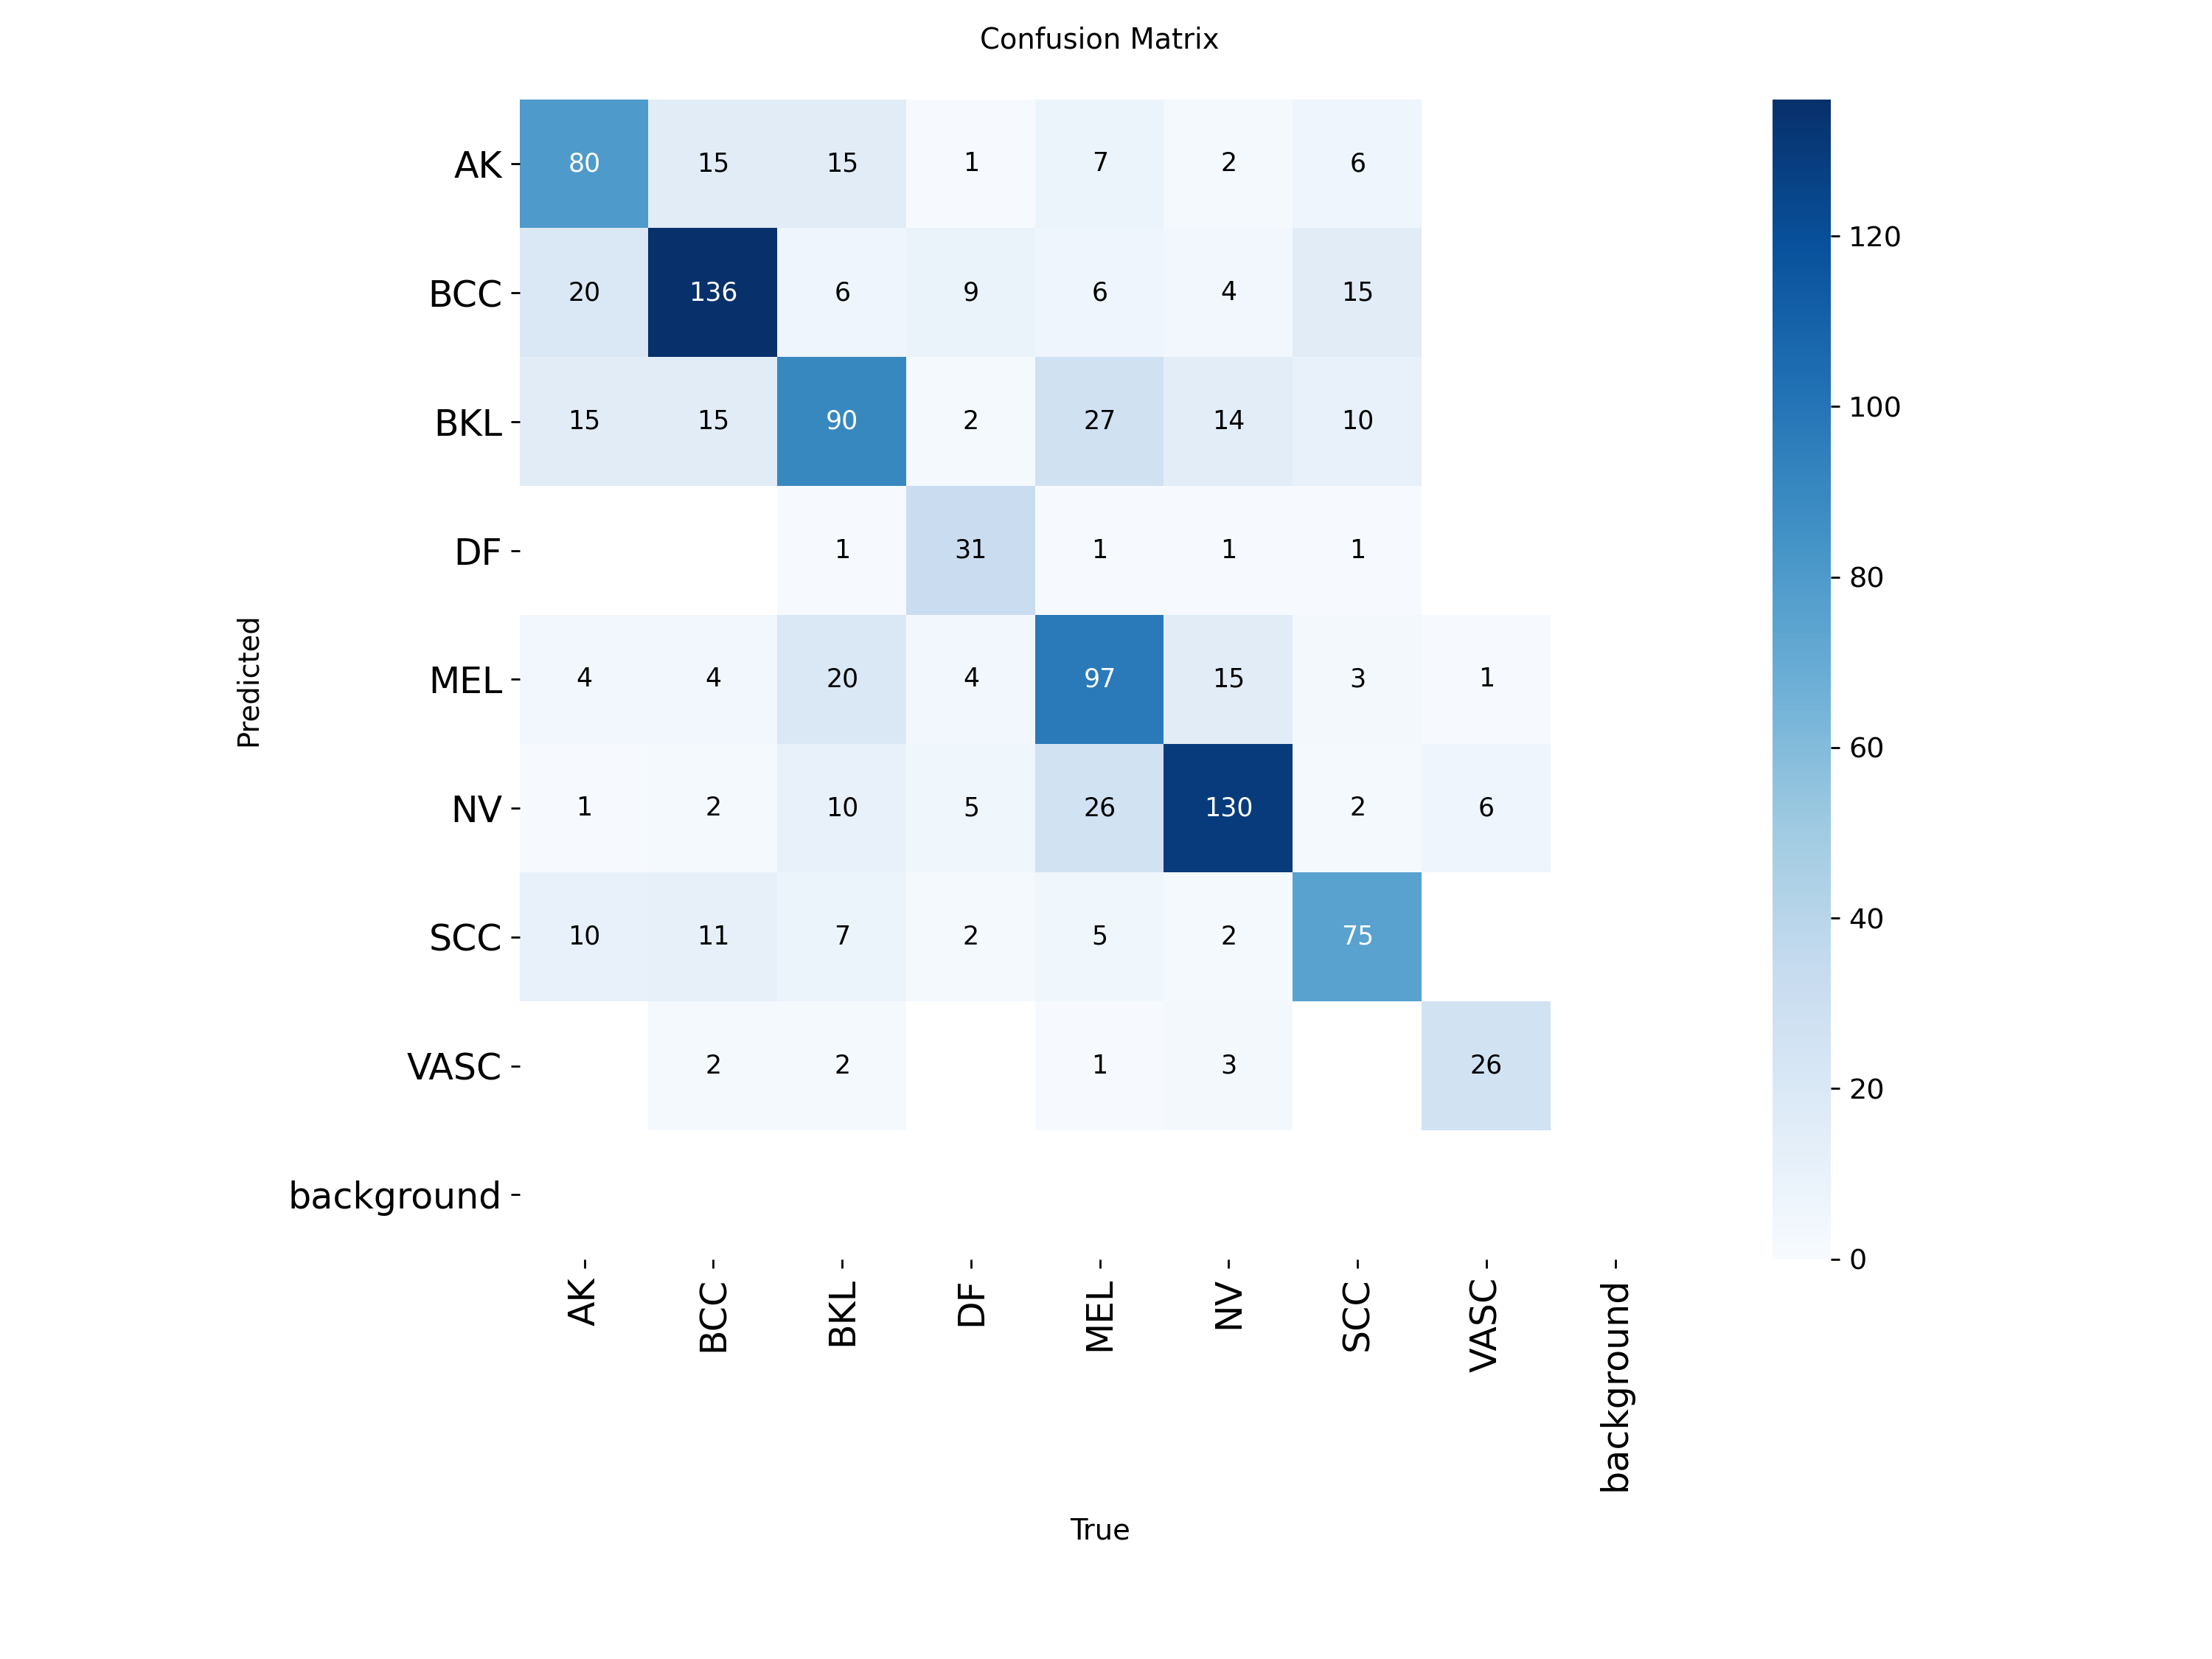

In [17]:
from IPython.display import Image
Image("/kaggle/working/runs/classify/val-2/confusion_matrix.png")


image 1/1 /kaggle/working/skin-lesion-classification-1/test/AK/ISIC_0058983_jpg.rf.14545f5ced36a95aa7e72ed085c271cf.jpg: 224x224 AK 0.92, BCC 0.07, SCC 0.01, MEL 0.00, BKL 0.00, 6.3ms
Speed: 1.5ms preprocess, 6.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Predicted: AK
Confidence: 91.96%
Actual class: AK


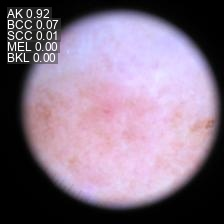

In [24]:
from ultralytics import YOLO
from IPython.display import Image as IPImage
import os

model = YOLO("/kaggle/working/skin_lesion_output/run1/weights/best.pt")

# Pick one test image automatically

test_dir = os.path.join(data_path, "test") 
# data_path is for going kaggle/working directory to test
first_class = sorted(os.listdir(test_dir))[0] 
#os.listdir(test_dir) looks inside your test/ folder and sees a list of subfolders: ['melanoma', 'carcinoma'].
#sorted(...) puts them in alphabetical order: ['carcinoma', 'melanoma'].
#[0] grabs the very first element in that list: "carcinoma".
#Result: first_class now holds the string value "carcinoma". This string is your ground-truth label!

test_image = os.path.join(test_dir, first_class, os.listdir(os.path.join(test_dir, first_class))[0])
#os.path.join(test_dir, first_class) points python to the path: skin_lesion_dataset/test/carcinoma/.
#os.listdir(...) looks inside that specific folder and lists all the images inside it: ['image_99.jpg', 'image_101.jpg'].
#[0] selects the first image file in that folder: "image_99.jpg".
#Result: test_image becomes the full path to that single image file: "/kaggle/working/skin_lesion_dataset/test/carcinoma/image_99.jpg".

results = model(test_image)

for r in results:
    print(f"Predicted: {r.names[r.probs.top1]}")
    print(f"Confidence: {r.probs.top1conf:.2%}")
    print(f"Actual class: {first_class}")

# Save and display
results[0].save(filename="/kaggle/working/test_prediction.jpg")
IPImage("/kaggle/working/test_prediction.jpg")